# 14. A custom posterior

<div class="callout callout-note">
Language: <strong>Python</strong> (Jupyter) - <a href="r.qmd">R version</a>
</div>

`mcmc_sample()` samples the posterior of a built-in distribution family under uniform priors
spanning that family's parameter constraints. `mcmc_posterior()` drops both restrictions: you
write the log-likelihood, you choose the priors, and all eight ported samplers become reachable,
including Gibbs, which neither package could run before this surface existed because Gibbs needs
a proposal function and there was no way to pass one in.

## What you'll learn

- Write a log-likelihood by hand and sample its posterior with `mcmc_posterior()`.
- Read the trace plot, R-hat and posterior summary the same way you would for a built-in model.
- Where the cross-language guarantee stops, and why a callback posterior is the place it stops
  hardest.
- Run the Gibbs sampler with a proposal function, drawing from the handle the sampler gives you
  rather than from `numpy.random`.

## Setup

In [1]:
import math

import numpy as np
import matplotlib.pyplot as plt

import corehydropy as ch

## A model the package does not have

Runoff against basin precipitation at a gauge, twelve water years, in inches. The model is a
straight line with Gaussian errors and three parameters: intercept $a$, slope $b$, and error
scale $\sigma$. No `model_*()` constructor builds this, so `fit_bayesian()` cannot reach it.

$$
y_i = a + b\,x_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)
$$

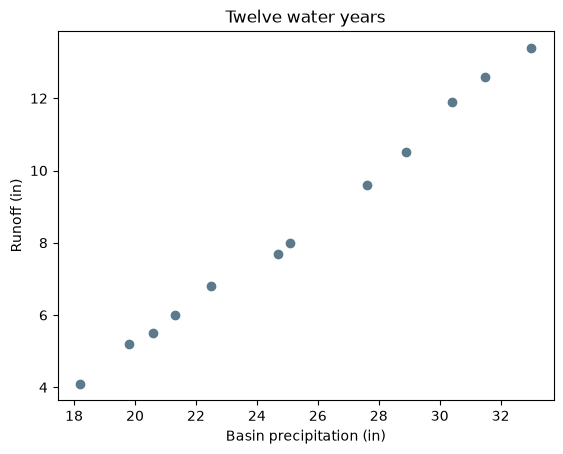

In [2]:
precip = [18.2, 22.5, 25.1, 19.8, 30.4, 27.6, 21.3, 33.0, 24.7, 28.9, 20.6, 31.5]
runoff = [4.1, 6.8, 8.0, 5.2, 11.9, 9.6, 6.0, 13.4, 7.7, 10.5, 5.5, 12.6]
n = len(runoff)

plt.scatter(precip, runoff, color="#5b7a8c", zorder=3)
plt.xlabel("Basin precipitation (in)")
plt.ylabel("Runoff (in)")
plt.title("Twelve water years")
plt.show()

Dropping the constant $-\tfrac{n}{2}\log(2\pi)$, the log-likelihood is

$$
\ell(a, b, \sigma) = -n \log \sigma
  - \frac{1}{2\sigma^2} \sum_{i=1}^{n} \bigl(y_i - a - b\,x_i\bigr)^2 .
$$

Written as a plain loop, which is deliberate and is explained in the next section.

In [3]:
def log_likelihood(p):
    a, b, sigma = p[0], p[1], p[2]
    acc = 0.0
    for i in range(n):
        resid = runoff[i] - (a + b * precip[i])
        acc += resid * resid
    return -n * math.log(sigma) - acc / (2 * sigma * sigma)

One prior per parameter, in the order `log_likelihood` reads them. These are flat, so the
log-likelihood carries no prior term: a parameter outside its prior's support is rejected before
your function is called, and the priors are used for the feasible bounds and for chain
initialization. A prior that is not flat would need its log density added to the returned value
yourself, which is the upstream contract rather than a corehydro choice.

In [4]:
priors = [
    ch.Distribution("Uniform", [-20, 10]),   # intercept
    ch.Distribution("Uniform", [0, 2]),      # slope
    ch.Distribution("Uniform", [0.01, 5]),   # error scale
]

fit = ch.mcmc_posterior(log_likelihood, priors, sampler="RWMH",
                        iterations=1000, warmup=500, chains=3, thinning=1,
                        seed=12345)

Keep the run small. Every evaluation crosses back into Python, and the count is
`(iterations + output_length / chains) * thinning * chains`, so a thinning interval or an unset
`iterations` costs far more than it looks like it should. This fit takes about a third of a
second.

### Trace plot

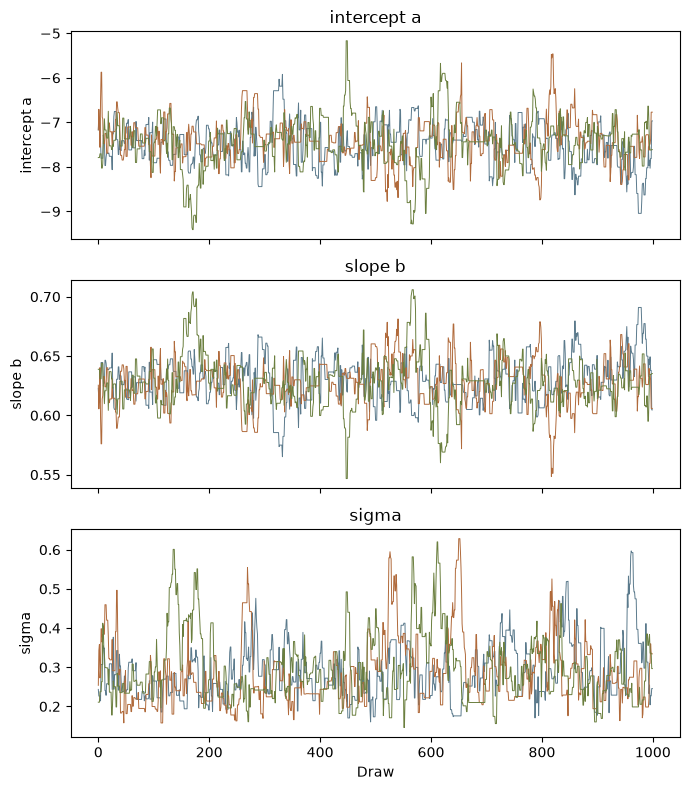

In [5]:
labels = ["intercept a", "slope b", "sigma"]
colors = ["#5b7a8c", "#b06a3b", "#6b7f3f"]

fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)
for j, ax in enumerate(axes):
    for c, chain_j in enumerate(fit["chains"]):
        ax.plot(chain_j[:, j], color=colors[c], linewidth=0.7)
    ax.set_ylabel(labels[j])
    ax.set_title(labels[j])
axes[-1].set_xlabel("Draw")
fig.tight_layout()
plt.show()

### R-hat and the posterior summary

R-hat compares between-chain and within-chain variance. Values near 1 mean the three chains have
settled on the same distribution.

In [6]:
header = f"{'parameter':>11} {'mean':>9} {'sd':>8} {'median':>9} {'lower':>9} {'upper':>9} {'rhat':>7} {'ess':>6}"
print(header)
for j, label in enumerate(labels):
    print(f"{label:>11} {fit['posterior_mean'][j]:9.4f} {fit['posterior_sd'][j]:8.4f} "
          f"{fit['posterior_median'][j]:9.4f} {fit['posterior_lower_ci'][j]:9.4f} "
          f"{fit['posterior_upper_ci'][j]:9.4f} {fit['rhat'][j]:7.4f} {fit['ess'][j]:6.0f}")

  parameter      mean       sd    median     lower     upper    rhat    ess
intercept a   -7.4538   0.4381   -7.4524   -8.1895   -6.7424  1.0003    881
    slope b    0.6284   0.0171    0.6281    0.6003    0.6573  1.0016    877
      sigma    0.2780   0.0697    0.2678    0.1835    0.4132  1.0015    468


The posterior mode is the MAP, reported alongside the value of your log-likelihood there.
Ordinary least squares is a useful cross-check on the two regression parameters, since with a
flat prior the mode of $(a, b)$ given $\sigma$ is the least-squares fit.

In [7]:
slope_ols, intercept_ols = np.polyfit(precip, runoff, 1)
print(f"MAP:  a = {fit['map'][0]:.6f}, b = {fit['map'][1]:.6f}, sigma = {fit['map'][2]:.6f}")
print(f"OLS:  a = {intercept_ols:.6f}, b = {slope_ols:.6f}")
print(f"log-likelihood at the MAP: {fit['map_fitness']:.6f}")

MAP:  a = -7.458993, b = 0.628485, sigma = 0.220553
OLS:  a = -7.459014, b = 0.628485
log-likelihood at the MAP: 12.139529


### The fitted line with its credible band

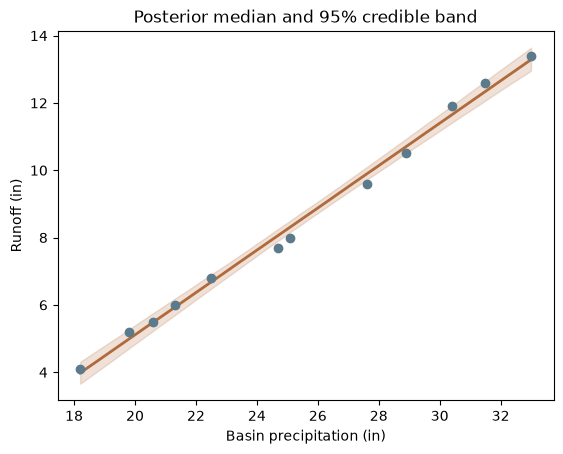

In [8]:
grid = np.linspace(min(precip), max(precip), 100)
draws = np.vstack(fit["chains"])
lines = draws[:, 0][:, None] + draws[:, 1][:, None] * grid[None, :]
lower, median, upper = np.percentile(lines, [2.5, 50, 97.5], axis=0)

plt.fill_between(grid, lower, upper, color="#b06a3b", alpha=0.2)
plt.plot(grid, median, color="#b06a3b", linewidth=2)
plt.scatter(precip, runoff, color="#5b7a8c", zorder=3)
plt.xlabel("Basin precipitation (in)")
plt.ylabel("Runoff (in)")
plt.title("Posterior median and 95% credible band")
plt.show()

## Where the cross-language guarantee stops

corehydro promises that a seeded run gives the same numbers in Python and in R. On the built-in
path that promise is unconditional: `mcmc_sample()`, `fit_bayesian()`, `Distribution.random()`
and the rest do every arithmetic operation inside the shared C++ core, so the two languages are
running the same compiled code and there is nothing left to disagree about.

`mcmc_posterior()` is weaker, and the difference deserves a section rather than a footnote. The
draws still come from the core's seeded Mersenne Twister, so the proposals are identical. The
log-density is not: it is your own Python arithmetic, evaluated by Python, and Python and R do
not guarantee identical rounding for the same formula. MCMC amplifies that without mercy. A
single differing bit in one log-density can flip one accept-or-reject decision, and every state
after it is then drawn from a different point, so the two chains diverge outright instead of
drifting apart slowly. There is no tolerance that repairs it.

A seeded run reproduces across the two languages if and only if your function returns
bit-identical values. Three practical rules follow.

1. `+`, `-`, `*` and `/` are IEEE-deterministic. They reproduce.
2. `log`, `exp`, `sqrt` of a non-exact value, `gamma` and friends come from each platform's own
   math library. They are not guaranteed to agree to the last bit, in either direction, and
   nothing in corehydro can make them.
3. R's `sum()` and `mean()` accumulate in extended precision. Python's do not. An explicit loop
   is the portable spelling in both languages, which is why the log-likelihood above is written
   as one.

The regression above obeys rules 1 and 3 but not rule 2: it calls `math.log(sigma)`. Measured on
this machine, the Python and R versions of that page happen to return identical posteriors to the
last bit, and the reproduction check below asserts those numbers as a within-Python regression
rather than as a cross-language claim, because the agreement is an observation about two math
libraries and not something the package guarantees. The Gibbs model in the next section uses
arithmetic and comparisons alone, which is why it is the one this page pins against the shared
oracle.

## Gibbs, the sampler that was out of reach

Gibbs replaces the Metropolis accept-or-reject step with a draw from the full conditional of the
model, which it accepts unconditionally. That draw is model-specific, so there is nothing
sensible to default it to, and until `mcmc_posterior()` existed neither package could run the
ported Gibbs sampler at all.

The model is small enough that its full conditional is exact. Five observations, each Uniform on
$(\mu - 1, \mu + 1)$. Dropping the normalizer, the log-likelihood is $0$ when every
$|x_i - \mu| \le 1$ and $-\infty$ otherwise, so under a flat prior the conditional of $\mu$ is
Uniform on $(\max x - 1, \min x + 1)$, here Uniform(4.2, 5.8). One uniform draw, rescaled, is the
Gibbs step.

In [9]:
x = [4.9, 5.1, 5.0, 5.2, 4.8]


def uniform_width(p):
    mu = p[0]
    for xi in x:
        d = xi - mu
        if d > 1.0 or d < -1.0:
            return float("-inf")
    return 0.0


def full_conditional(parameters, rng):
    lo = max(x) - 1.0
    hi = min(x) + 1.0
    return [lo + rng.uniform(1)[0] * (hi - lo)]

`rng` is a handle on the generator this chain is already running on, not a generator of your
own. Drawing with `numpy.random` instead is not an error and nothing will warn you, but it
silently breaks two guarantees: the run stops being reproducible from its seed, and it stops
agreeing with the same run in R. `rng.uniform(n)` returns `n` values on `[0, 1)`;
`rng.integers(n, min, max)` returns whole numbers with `min` included and `max` excluded. The
handle is borrowed for the duration of the one call it was given to, so storing it and drawing
from it later raises an error rather than reading freed memory.

In [10]:
gibbs = ch.mcmc_posterior(uniform_width, [ch.Distribution("Uniform", [0.0, 10.0])],
                          sampler="Gibbs", proposal=full_conditional,
                          iterations=300, warmup=100, thinning=1,
                          seed=12345, initialize="Randomize")

chain = gibbs["chains"][0]
print(f"draws: {chain.shape[0]}, parameters: {chain.shape[1]}, chains: {len(gibbs['chains'])}")
print(f"acceptance rate: {gibbs['acceptance_rates'][0]:g}")
print(f"MAP: {gibbs['map'][0]:.16g}   log-likelihood there: {gibbs['map_fitness']:g}")
print("first, middle and last states: "
      f"{chain[0, 0]:.16g}, {chain[150, 0]:.16g}, {chain[299, 0]:.16g}")

draws: 300, parameters: 1, chains: 1
acceptance rate: 0
MAP: 5.731063370779157   log-likelihood there: 0
first, middle and last states: 4.369926358014346, 4.430059107020497, 4.246628397703171


Two of those numbers look wrong at first and are not. The acceptance rate is exactly 0 because
Gibbs draws from the exact conditional and the upstream sampler counts no Metropolis accepts at
all. The log-likelihood at the MAP is exactly 0 because this kernel returns 0 everywhere inside
its support, which also means the MAP is whichever state the chain visited first at that height,
making it a pin on the order of the draws rather than on their values.

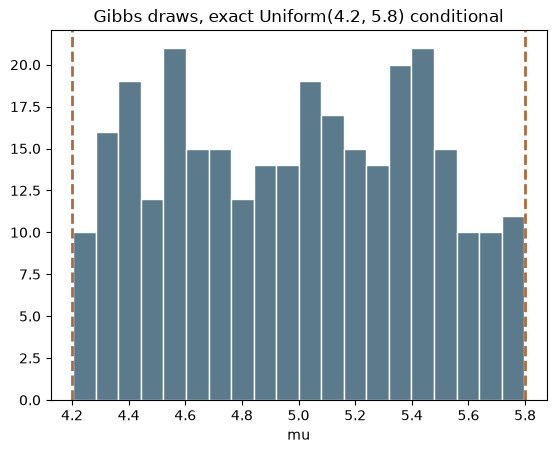

In [11]:
plt.hist(chain[:, 0], bins=20, color="#5b7a8c", edgecolor="white")
for edge in (4.2, 5.8):
    plt.axvline(edge, color="#b06a3b", linewidth=2, linestyle="--")
plt.xlabel("mu")
plt.title("Gibbs draws, exact Uniform(4.2, 5.8) conditional")
plt.show()

## Key takeaways

1. `mcmc_posterior()` takes any log-likelihood you can write as a Python callable, over priors
   you choose, and reaches all eight ported samplers.
2. Flat priors need no term in your log-likelihood. Anything else does, and adding it is your
   job, following the upstream contract.
3. The cross-language guarantee is conditional on the callback path. It holds exactly when your
   function returns bit-identical values, so arithmetic and explicit loops hold it and calls into
   a platform math library are not guaranteed to.
4. Gibbs needs a proposal, and the proposal must draw from the handle it is given. Reaching for
   `numpy.random` runs fine and quietly costs you reproducibility.
5. Keep callback runs small. The evaluation count is
   `(iterations + output_length / chains) * thinning * chains`, and `initialize="MAP"` runs a
   differential evolution fit over your function before the first iteration.

## Reproduction check

The Gibbs block below is pinned against `fixtures/callback/callback_cross_language.json`, whose
values are read from the real USACE-RMC Numerics library by the oracle emitter. That fixture
asserts this exact construct at ZERO tolerance, not at a loosened one: the C++, R, Python and C#
runners reproduce it bit for bit, because both callbacks are built from arithmetic and
comparisons alone. It is checked at 1e-15 relative tolerance here only to match the convention
the other example pages use.

Two of the fixture's numbers are deliberately absent below, and the reason is worth stating. The
fixture sets the sampler's `output_length` to 100, an option `mcmc_posterior()` does not expose,
and the posterior mean and median are computed over that output block rather than over the
recorded chain. Left at the ported Gibbs default of 10,000 the same run reports 5.003896 rather
than the fixture's 4.984070. The chain itself is untouched by this, which is why every state, the
MAP, the fitness and the acceptance rate below are the fixture's own values. The mean and median
are asserted at what this call returns, and Python and R return the same double for both.

The regression numbers are a within-Python regression check on this page, not a cross-language
claim, for the reason given in the cross-language section above.

In [12]:
def near(value, literal, tol=1e-15):
    return abs(value / literal - 1) < tol


# Gibbs, against the shared fixture oracle.
assert chain.shape == (300, 1) and len(gibbs["chains"]) == 1
assert near(gibbs["map"][0], 5.7310633707791565)
assert gibbs["map_fitness"] == 0
assert gibbs["acceptance_rates"][0] == 0
assert near(chain[0, 0], 4.369926358014346)
assert near(chain[150, 0], 4.430059107020497)
assert near(chain[299, 0], 4.246628397703171)

# Gibbs summary statistics, over the default 10,000-draw output block (see above). Python and R
# return the same double for each.
assert near(gibbs["posterior_mean"][0], 5.0038958189989167)
assert near(gibbs["posterior_median"][0], 5.0066633708775043)

# The regression posterior, within Python only.
assert near(fit["posterior_mean"][0], -7.4538132847773335)
assert near(fit["posterior_mean"][1], 0.6283589815314603)
assert near(fit["posterior_mean"][2], 0.27803652002522816)
assert near(fit["map_fitness"], 12.139529268441548)
assert all(r < 1.01 for r in fit["rhat"])

# The MAP of the two regression parameters agrees with least squares.
assert abs(fit["map"][0] - intercept_ols) < 0.01
assert abs(fit["map"][1] - slope_ols) < 0.001

print("All reproduction checks passed.")

All reproduction checks passed.
